
E-Waste Image Classification Using EfficientNetV2B0 (Transfer Learning)

Problem Statement and Description

E-waste (electronic waste) is rapidly becoming a serious environmental and health issue around the world. Proper sorting and categorization of e-waste is essential for efficient recycling and disposal, but manual classification is error-prone and labor-intensive.

This project aims to build an automated e-waste classification system using artificial intelligence and machine learning. By training a deep learning model on images of different types of e-waste, we can identify and categorize them accurately.

Goal:

Use image classification with EfficientNetV2B0 to classify e-waste into 10 distinct categories to support better sorting and recycling automation.


Dataset Overview

Dataset Name: E-Waste Image Dataset

Source: https://www.kaggle.com/datasets/akshat103/e-waste-image-dataset

Each directory contains 10 subfolders, each representing one class of e-waste:

PCB (Printed Circuit Board)

Player

Battery

Microwave

Mobile

Mouse

Printer

Television

Washing Machine

Keyboard


What is Transfer Learning?

Transfer Learning: Transfer Learning is a machine learning technique where a pre-trained model developed for a specific task is reused as the starting point for a model on a different but related task. It also allows us to build accurate models in a time-saving way by starting from patterns learned when solving a different problem. This approach is beneficial when there is limited data for the new task, as the pre-trained model already has learned features that can be adapted. Transfer learning can significantly improve models' performance and efficiency in domains like computer vision and natural language processing.

Benefits

Reduces training time — you don't start from scratch.

Leverages learned features from large datasets (like ImageNet).

Improves performance, especially with limited data.


How Does It Work?

Load a pretrained model (e.g., ResNet, EfficientNet).

Freeze the pretrained layers (optional).

Add new layers for your custom task.

Train on your new dataset (can also fine-tune).

EfficientNetV2B0: Transfer Learning Backbone

Overview

EfficientNetV2 is an optimized family of models introduced by Google for efficient training and inference.

Key Features:

Fused MBConv blocks — improve training speed and GPU efficiency.

Progressive learning — gradually increases input size during training.

Better accuracy with fewer parameters and FLOPs.

Why Use EfficientNetV2B0?

Lightweight - Small model size, ideal for mobile & edge devices

Fast - Quick training and inference

Pretrained on ImageNet - Excellent feature extraction baseline

High Accuracy - Competitively performs even in low-resource setups

In [1]:
!pip install tensorflow

In [2]:
!unzip "E-Waste classification dataset.zip"

Archive:  E-Waste classification dataset.zip
  inflating: modified-dataset/test/Battery/battery_106.jpg  
  inflating: modified-dataset/test/Battery/battery_128.jpg  
  inflating: modified-dataset/test/Battery/battery_148.jpg  
  inflating: modified-dataset/test/Battery/battery_152.jpg  
  inflating: modified-dataset/test/Battery/battery_174.jpg  
  inflating: modified-dataset/test/Battery/battery_177.jpg  
  inflating: modified-dataset/test/Battery/battery_190.jpg  
  inflating: modified-dataset/test/Battery/battery_192.jpg  
  inflating: modified-dataset/test/Battery/battery_211.jpg  
  inflating: modified-dataset/test/Battery/battery_22.jpg  
  inflating: modified-dataset/test/Battery/battery_24.jpg  
  inflating: modified-dataset/test/Battery/battery_241.jpg  
  inflating: modified-dataset/test/Battery/battery_242.jpg  
  inflating: modified-dataset/test/Battery/battery_251.jpg  
  inflating: modified-dataset/test/Battery/battery_259.jpg  
  inflating: modified-dataset/test/Battery

Core Libraries

tensorflow: For deep learning model building and training.

numpy: For numerical operations and array manipulation.

matplotlib.pyplot: For plotting training curves and results.

In [3]:
import tensorflow as tf

from tensorflow.keras import layers, models, optimizers, callbacks

from tensorflow.keras.models import Sequential, load_model

from tensorflow.keras.applications import EfficientNetV2B0

from tensorflow.keras.applications.efficientnet import preprocess_input

import numpy as np

import matplotlib.pyplot as plt

import seaborn as sns

from sklearn.metrics import confusion_matrix, classification_report



from PIL import Image

Format: Folder-based image classification dataset

Train/: Images used for training the model

Test/: Images used for model evaluation

Validation/: Images used to fine-tune and validate the model

In [4]:
trainpath = "/content/modified-dataset/train"
validpath = "/content/modified-dataset/val"
testpath  = "/content/modified-dataset/test"

1. Explore and Understand the Data

Load image dataset using tools like image_dataset_from_directory.

Visualize sample images from each class.

Check the number of images per class to ensure balance.

Understand image dimensions, color channels, and class labels.

Load image dataset using tools like image_dataset_from_directory.

Split data into training, validation, and testing sets.

tf.keras.utils.image_dataset_from_directory(...)

Used to load images from a directory where each subfolder represents a class.

path

Root directory path containing one subdirectory per class.

shuffle=True

Randomly shuffles the image data. Useful during training to prevent the model from learning the order of the data.

image_size=(128, 128)

Resizes all loaded images to this target size (width, height).
This must match the input size expected by the model.

batch_size=32

Number of images per batch during training.
This affects memory usage and the frequency of model updates.

validation_split=False

If set to a float (e.g., 0.2), splits a portion of the data for validation.
If False, no split is applied.

In [5]:
datatrain= tf.keras.utils.image_dataset_from_directory(trainpath,shuffle = True, image_size = (128,128), batch_size = 32, validation_split= False)
datatest=tf.keras.utils.image_dataset_from_directory(testpath,shuffle = False, image_size = (128,128), batch_size = 32, validation_split= False)
datavalid = tf.keras.utils.image_dataset_from_directory(validpath,shuffle = True, image_size = (128,128), batch_size = 32, validation_split= False)
print(len(datatrain.class_names))
class_names = datatrain.class_names
print(class_names)

Found 2400 files belonging to 10 classes.
Found 300 files belonging to 10 classes.
Found 300 files belonging to 10 classes.
10
['Battery', 'Keyboard', 'Microwave', 'Mobile', 'Mouse', 'PCB', 'Player', 'Printer', 'Television', 'Washing Machine']


Visualize sample images from each class.

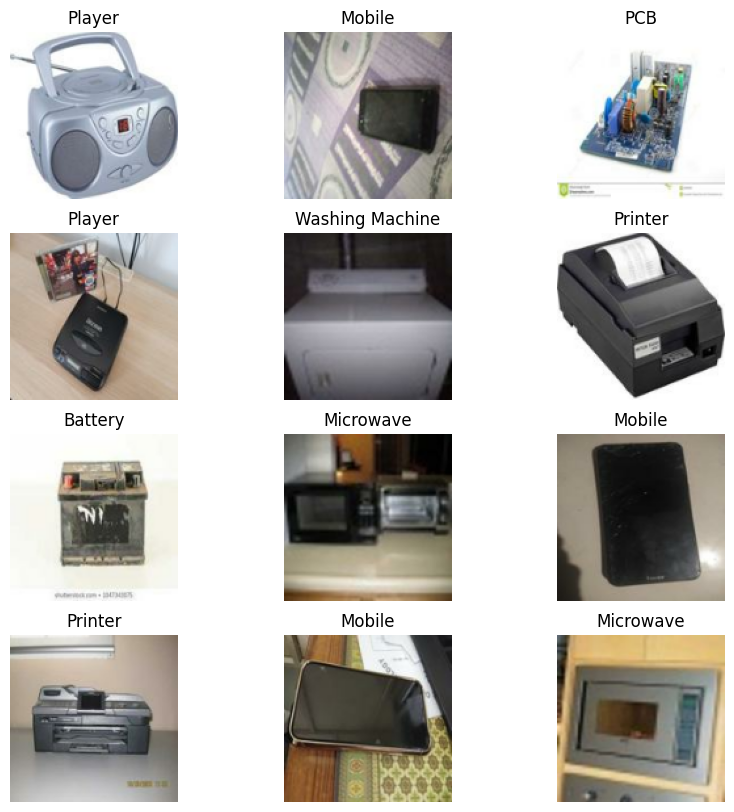

In [6]:
plt.figure(figsize=(10, 10))


for images, labels in datatrain.take(1):

    for i in range(12):

        ax = plt.subplot(4, 3, i + 1)


        plt.imshow(images[i].numpy().astype("uint8"))


        plt.title(class_names[labels[i]])


        plt.axis("off")

In [7]:
def plot_class_distribution(dataset, title="Class Distribution"):
    class_counts = {}

    for images, labels in dataset:
        for label in labels.numpy():
            class_name = dataset.class_names[label]
            class_counts[class_name] = class_counts.get(class_name, 0) + 1

    class_names = list(class_counts.keys())
    counts = list(class_counts.values())

    import matplotlib.pyplot as plt
    plt.figure(figsize=(10, 6))
    plt.bar(class_names, counts, color='skyblue')
    plt.xlabel("Class")
    plt.ylabel("Number of Items")
    plt.title(title)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

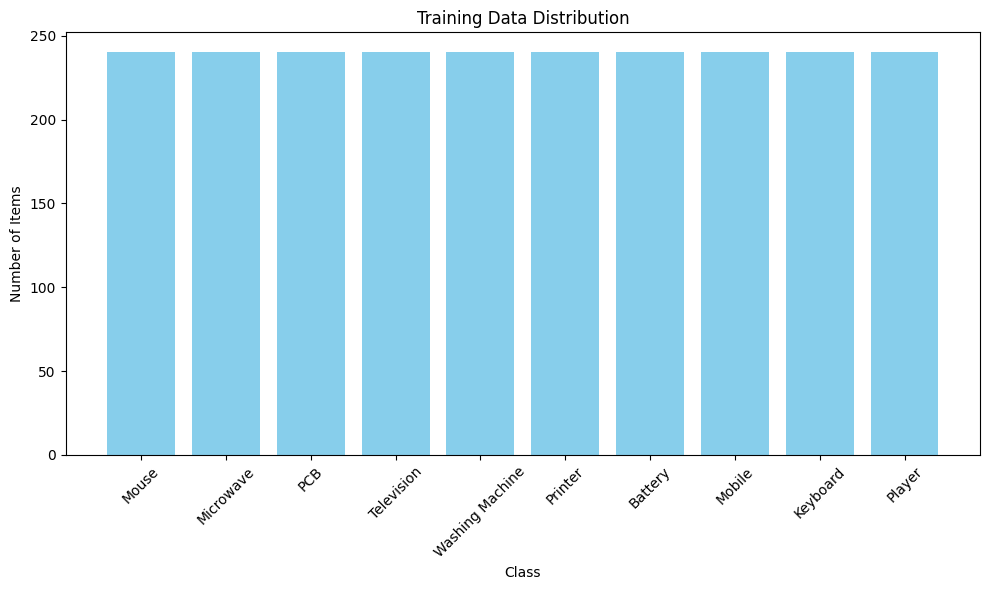

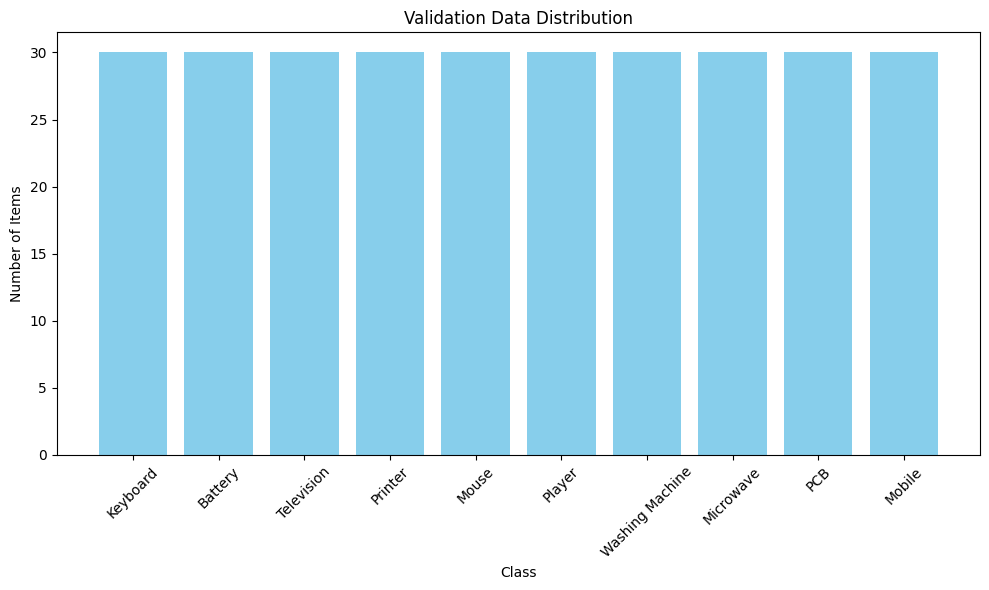

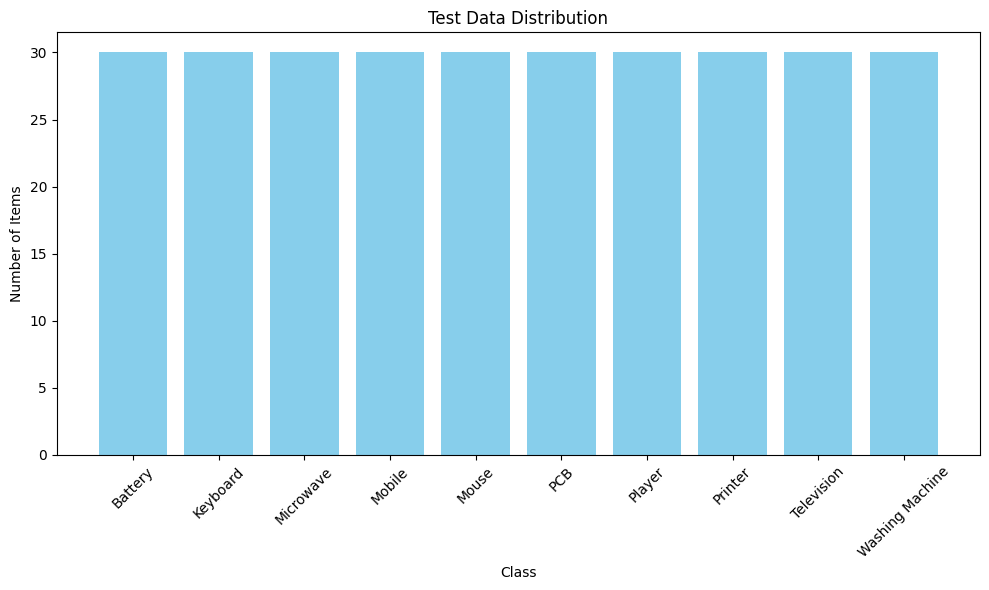

In [8]:
plot_class_distribution(datatrain, "Training Data Distribution")
plot_class_distribution(datavalid, "Validation Data Distribution")
plot_class_distribution(datatest, "Test Data Distribution")

2. Data Preprocessing / Preparation

Resize and rescale images.

Apply data augmentation (e.g., RandomFlip, RandomRotation, RandomZoom) to improve generalization.

Normalize images (using preprocess_input if using pre-trained models like EfficientNet).

In [9]:

data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
])

3. Model Selection

Choose a base model: Custom CNN or Transfer Learning (e.g., EfficientNetV2B0).

Decide whether to use pre-trained weights (e.g., ImageNet).

Define whether layers should be trainable or frozen during initial training.

In [10]:
base_model = tf.keras.applications.EfficientNetV2B0(
    input_shape=(128, 128, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = True
for layer in base_model.layers[:100]:
    layer.trainable = False

24274472/24274472 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


4. Model Training

Build the model architecture using Sequential or Functional API.

Compile the model with loss function ( sparse_categorical_crossentropy), optimizer (e.g., Adam), and evaluation metrics (accuracy).

5. Model Tuning and Optimization

Tune hyperparameters: learning rate, batch size, number of layers, dropout rate.

Use callbacks: EarlyStopping,

Optionally perform fine-tuning on pre-trained models by unfreezing some layers.

Model Architecture and Layer Utilities

Sequential: A simple way to build models by stacking layers one after the other in a linear fashion.

RandomFlip: A data augmentation layer that flips input images horizontally or vertically at random, helping the model generalize better.

RandomRotation: Randomly rotates images by a specified angle range during training to make the model invariant to orientation.

RandomZoom: Applies random zoom-in or zoom-out to training images, helping the model recognize objects at various scales.

Dropout: A regularization method that randomly "drops" (sets to zero) a fraction of input units during training to prevent overfitting.

GlobalAveragePooling2D: Reduces each feature map to a single number by taking the average, reducing model parameters and helping prevent overfitting.

Dense: A fully connected neural network layer used to learn complex features and typically found at the end of the model for classification.

Input: Specifies the input shape and data type for the model; acts as the starting point of the model architecture.

EfficientNetV2B0: A pre-trained convolutional neural network from the EfficientNetV2 family, known for being lightweight and high-performing, commonly used for transfer learning.

In [11]:
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(128, 128, 3)),
    data_augmentation,
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(10, activation='softmax')
])
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),loss = tf.keras.losses.SparseCategoricalCrossentropy(), metrics=['Accuracy'])

Train the model using .fit() with appropriate epochs, batch_size, and callbacks like EarlyStopping.

In [12]:
early = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

history = model.fit(
    datatrain,
    validation_data=datavalid,
    epochs=15,
    batch_size=32,
    callbacks=[early]
)

Epoch 1/15
75/75 ━━━━━━━━━━━━━━━━━━━━ 45s 135ms/step - Accuracy: 0.4225 - loss: 1.8244 - val_Accuracy: 0.7867 - val_loss: 1.1174
Epoch 2/15
75/75 ━━━━━━━━━━━━━━━━━━━━ 7s 88ms/step - Accuracy: 0.7975 - loss: 0.8950 - val_Accuracy: 0.9133 - val_loss: 0.4936
Epoch 3/15
75/75 ━━━━━━━━━━━━━━━━━━━━ 6s 76ms/step - Accuracy: 0.8742 - loss: 0.4987 - val_Accuracy: 0.9367 - val_loss: 0.2778
Epoch 4/15
75/75 ━━━━━━━━━━━━━━━━━━━━ 7s 86ms/step - Accuracy: 0.9058 - loss: 0.3374 - val_Accuracy: 0.9600 - val_loss: 0.2055
Epoch 5/15
75/75 ━━━━━━━━━━━━━━━━━━━━ 6s 76ms/step - Accuracy: 0.9275 - loss: 0.2610 - val_Accuracy: 0.9533 - val_loss: 0.1906
Epoch 6/15
75/75 ━━━━━━━━━━━━━━━━━━━━ 7s 90ms/step - Accuracy: 0.9550 - loss: 0.1842 - val_Accuracy: 0.9567 - val_loss: 0.1676
Epoch 7/15
75/75 ━━━━━━━━━━━━━━━━━━━━ 6s 76ms/step - Accuracy: 0.9567 - loss: 0.1535 - val_Accuracy: 0.9567 - val_loss: 0.1605
Epoch 8/15
75/75 ━━━━━━━━━━━━━━━━━━━━ 7s 86ms/step - Accuracy: 0.9650 - loss: 0.1316 - val_Accuracy: 0.9567 -

Model Architechure of EfficientNETV2

In [13]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetv2-b0 (Functional)  │ (None, 4, 4, 1280)     │     5,919,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │        12,810 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,269,040 (62.06 MB)

 Trainable params: 5,168,458 (19.72 MB)

 Non-trainable params: 763,664 (2.91 MB)

 Optimizer params: 10,336,918 (39.43 MB)

In [14]:

base_model.summary()

Model: "efficientnetv2-b0"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 128, 128,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 128, 128,  │          0 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 64, 64,    │        864 │ normalization[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 64, 64,    │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 64, 64,    │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 64, 64,    │      4,608 │ stem_activation[… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_bn  │ (None, 64, 64,    │         64 │ block1a_project_… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_ac… │ (None, 64, 64,    │          0 │ block1a_project_… │
│ (Activation)        │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_expand_conv │ (None, 32, 32,    │      9,216 │ block1a_project_… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_expand_bn   │ (None, 32, 32,    │        256 │ block2a_expand_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_expand_act… │ (None, 32, 32,    │          0 │ block2a_expand_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_project_co… │ (None, 32, 32,    │      2,048 │ block2a_expand_a… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_project_bn  │ (None, 32, 32,    │        128 │ block2a_project_… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2b_expand_conv │ (None, 32, 32,    │     36,864 │ block2a_project_… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2b_expand_bn   │ (None, 32, 32,    │        512 │ block2b_expand_c… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2b_expand_act… │ (None, 32, 32,    │          0 │ block2b_expand_b

 Total params: 5,919,312 (22.58 MB)

 Trainable params: 5,155,648 (19.67 MB)

 Non-trainable params: 763,664 (2.91 MB)


Model Performance Visualization: Accuracy & Loss Trends

In [15]:
acc = history.history['Accuracy']           # Training accuracy
val_acc = history.history['val_Accuracy']   # Validation accuracy
loss = history.history['loss']              # Training loss
val_loss = history.history['val_loss']

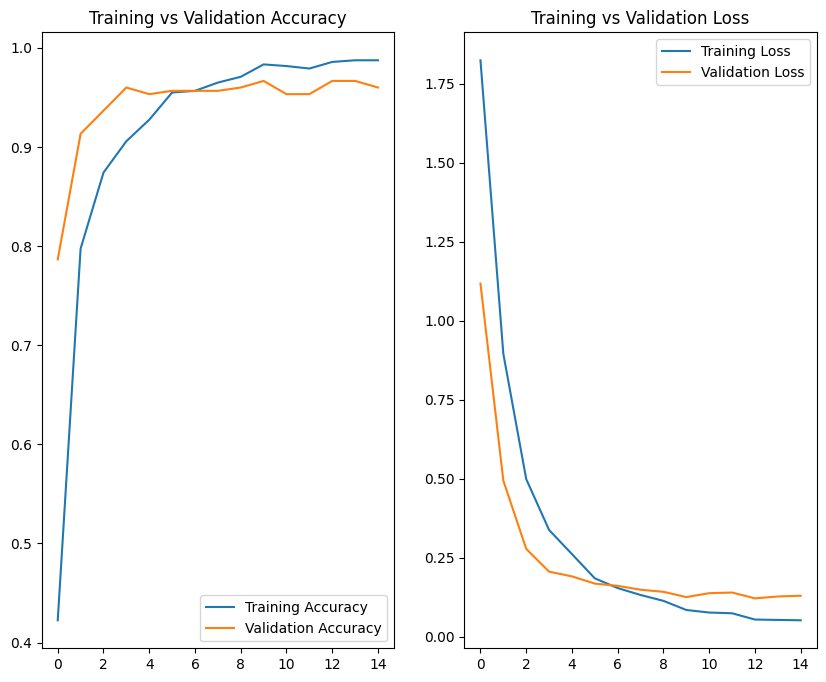

In [16]:

epochs_range = range(len(acc))              # X-axis range based on number of epochs

plt.figure(figsize=(10, 8))                 # Set overall figure size

plt.subplot(1, 2, 1)                        # 1 row, 2 columns, position 1
plt.plot(epochs_range, acc, label='Training Accuracy')       # Plot training accuracy
plt.plot(epochs_range, val_acc, label='Validation Accuracy') # Plot validation accuracy
plt.legend(loc='lower right')              # Show legend at lower right
plt.title('Training vs Validation Accuracy') # Set title for accuracy plot

plt.subplot(1, 2, 2)                        # 1 row, 2 columns, position 2
plt.plot(epochs_range, loss, label='Training Loss')          # Plot training loss
plt.plot(epochs_range, val_loss, label='Validation Loss')    # Plot validation loss
plt.legend(loc='upper right')              # Show legend at upper right
plt.title('Training vs Validation Loss')    # Set title for loss plot

plt.show()

6. Model Evaluation

Plot training and validation accuracy/loss curves.

Evaluate model performance on validation or test set.

Use metrics like:

Confusion Matrix

Classification Report (Precision, Recall, F1-score)

confusion_matrix, classification_report: To evaluate the model's classification performance.

In [17]:
loss, accuracy = model.evaluate(datatest)
print(f'Test accuracy is{accuracy:.4f}, Test loss is {loss:.4f}')

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - Accuracy: 0.9533 - loss: 0.1539
Test accuracy is0.9533, Test loss is 0.1539


In [18]:
y_true = np.concatenate([y.numpy() for x, y in datatest], axis=0)  # Ground truth labels

# Get predictions as probabilities and then predicted classes
y_pred_probs = model.predict(datatest)

# Class with highest probability
y_pred = np.argmax(y_pred_probs, axis=1)

# Print confusion matrix and classification report
print(confusion_matrix(y_true, y_pred))
print(classification_report(y_true, y_pred))

10/10 ━━━━━━━━━━━━━━━━━━━━ 5s 283ms/step
[[28  0  0  0  0  2  0  0  0  0]
 [ 2 28  0  0  0  0  0  0  0  0]
 [ 0  0 29  0  0  0  0  1  0  0]
 [ 0  0  0 30  0  0  0  0  0  0]
 [ 0  0  0  0 30  0  0  0  0  0]
 [ 0  0  0  0  0 29  1  0  0  0]
 [ 2  0  1  0  1  0 26  0  0  0]
 [ 0  0  0  0  0  0  0 30  0  0]
 [ 0  0  2  1  0  0  1  0 26  0]
 [ 0  0  0  0  0  0  0  0  0 30]]
              precision    recall  f1-score   support

           0       0.88      0.93      0.90        30
           1       1.00      0.93      0.97        30
           2       0.91      0.97      0.94        30
           3       0.97      1.00      0.98        30
           4       0.97      1.00      0.98        30
           5       0.94      0.97      0.95        30
           6       0.93      0.87      0.90        30
           7       0.97      1.00      0.98        30
           8       1.00      0.87      0.93        30
           9       1.00      1.00      1.00        30

    accuracy                    

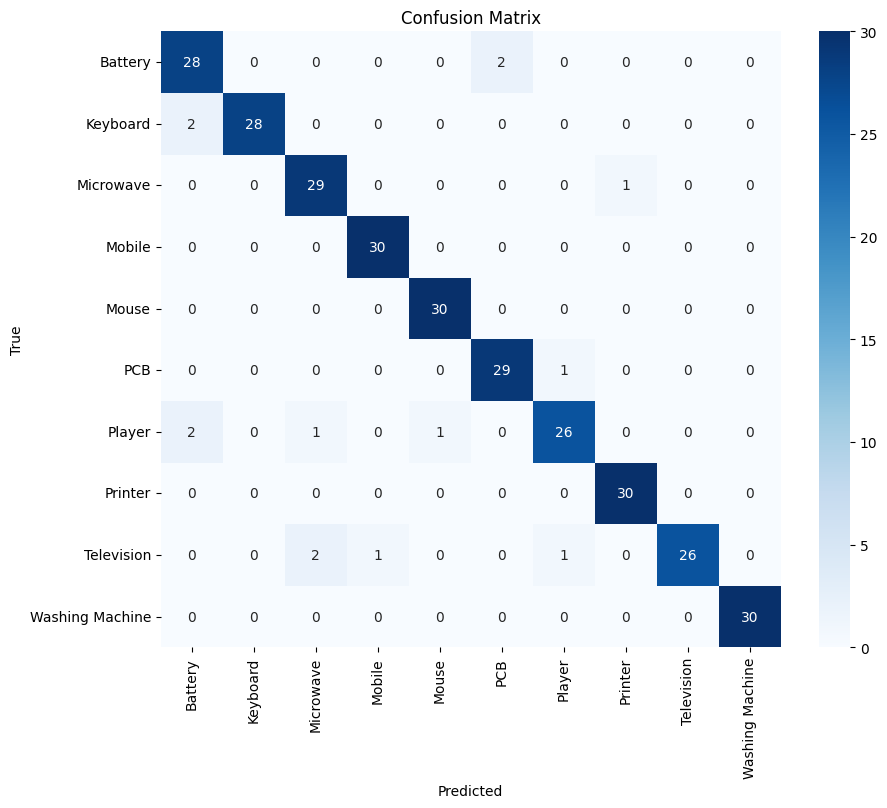

In [19]:

cm = confusion_matrix(y_true, y_pred)                                     # Compute confusion matrix
                                                     # Import seaborn for visualization

plt.figure(figsize=(10, 8))                                               # Set figure size
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=class_names,
            yticklabels=class_names,
            cmap='Blues')                                                 # Create heatmap with class labels

plt.xlabel('Predicted')                                                   # Label for x-axis
plt.ylabel('True')                                                        # Label for y-axis
plt.title('Confusion Matrix')                                             # Title for the plot
plt.show()


7. Final Testing and Save the Model

Evaluate the final model on the unseen test dataset.

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step


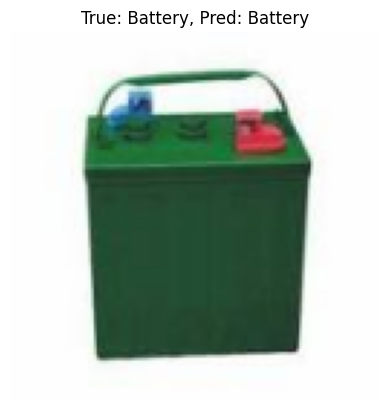

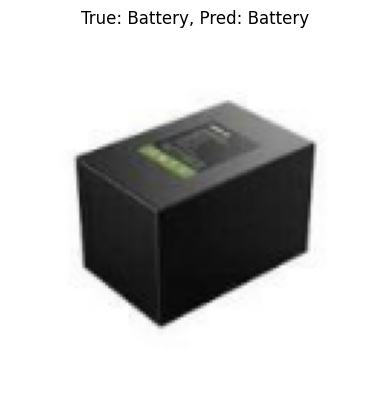

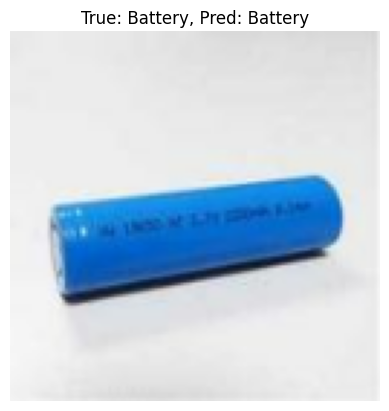

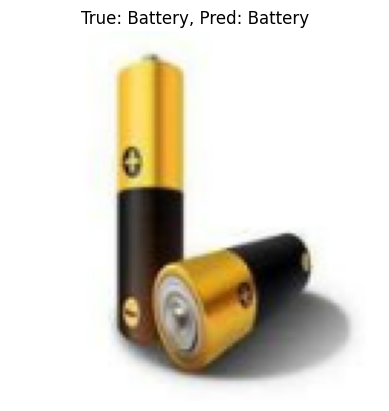

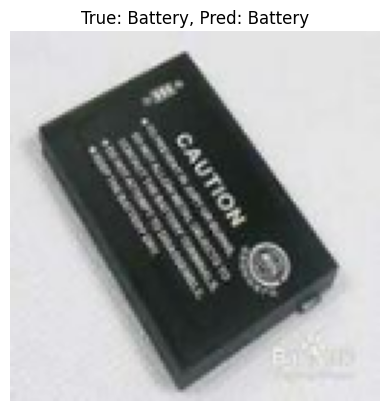

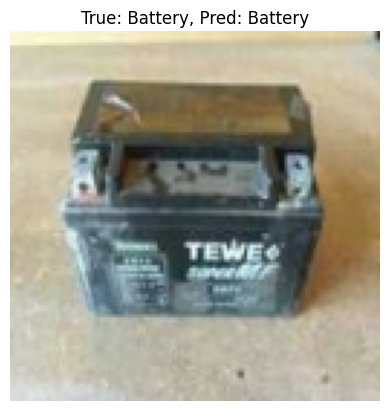

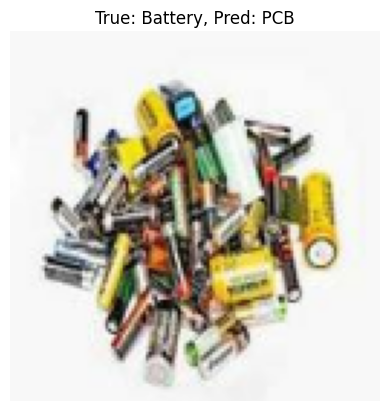

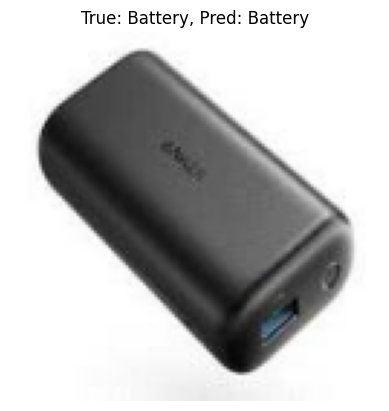

In [20]:
class_names = datatest.class_names                                           # Get class names from test dataset

for images, labels in datatest.take(1):                                     # Take one batch from test data
    predictions = model.predict(images)                                     # Predict class probabilities
    pred_labels = tf.argmax(predictions, axis=1)                            # Get predicted class indices

    for i in range(8):                                                      # Display first 8 images from batch
        plt.imshow(images[i].numpy().astype("uint8"))                       # Convert tensor to image
        plt.title(f"True: {class_names[labels[i]]}, Pred: {class_names[pred_labels[i]]}")  # Title with labels
        plt.axis("off")                                                     # Hide axes
        plt.show()

In [ ]:
model.save('Efficient_classify.keras')

In [ ]:
class_names = ['Battery', 'Keyboard', 'Microwave', 'Mobile', 'Mouse', 'PCB', 'Player', 'Printer', 'Television', 'Washing Machine']

In [ ]:
model = tf.keras.models.load_model('Efficient_classify.keras')

8. Model Deployment

In [21]:
!pip install gradio

In [22]:
def classify_image(img):
    import numpy as np
    from PIL import Image


    if img is None:
        return "No image received"


    if isinstance(img, np.ndarray):
        img = Image.fromarray(img)

    img = img.convert("RGB")
    img = img.resize((128, 128))
    img_array = np.array(img, dtype=np.float32)

    img_array = preprocess_input(img_array)
    img_array = np.expand_dims(img_array, axis=0)

    prediction = model.predict(img_array)
    index = np.argmax(prediction)

    class_name = class_names[index]
    confidence = prediction[0][index]

    return f"Predicted: {class_name} (Confidence: {confidence:.2f})"

In [23]:
import gradio as gr
iface = gr.Interface(
    fn=classify_image,          # The function to run when input is given
    inputs=gr.Image(type="numpy"), # Input component: expects an image as a PIL object
    outputs="text"              # Output component: displays the result as plain text
)

# Launch the Gradio interface, opening a local web app to interact with the model
iface.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://4c541bfb9e86d42bbe.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
